In [ ]:
import cv2
import numpy as np
import os

DATA_DIR = 'data/real'
IMG_SIZE = 96

Load SOCOFing data from kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ruizgara/socofing")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'socofing' dataset.
Path to dataset files: /kaggle/input/socofing


In [ ]:
import os
import shutil

# 1. Download latest version (Saves to the Kaggle Cache)
path = kagglehub.dataset_download("ruizgara/socofing")

# 2. Define Source Path: The location of the images within the cache
SOURCE_DIR = os.path.join(path, "SOCOFing", "Real")

print(f"Kaggle cache path root: {path}")
print(f"Kaggle cache path for 'real' images: {SOURCE_DIR}")
print(f"Project destination path: {DATA_DIR}")

# 3. Ensure the destination folder in your project is created
os.makedirs(DATA_DIR, exist_ok=True)
print("Destination directory ensured.")

# 4. Copy files from cache to project directory
print("Starting file COPY from cache to project directory...")
copied_count = 0

if not os.path.isdir(SOURCE_DIR):
    print("\nERROR: Source directory not found in cache. Did a previous 'shutil.move' empty it?")
    print("Please manually check the cache path printed above.")
else:
    for filename in os.listdir(SOURCE_DIR):
        source_path = os.path.join(SOURCE_DIR, filename)
        dest_path = os.path.join(DATA_DIR, filename)

        if filename.endswith(".BMP") and os.path.isfile(source_path):
            shutil.copy2(source_path, dest_path)
            copied_count += 1

    print(f"\nSuccessfully copied {copied_count} files to {DATA_DIR}.")

100%|██████████| 838M/838M [00:07<00:00, 121MB/s]

Extracting files...


Kaggle cache path root: /root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2
Kaggle cache path for 'real' images: /root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing/Real
Project destination path: data/real
Destination directory ensured.
Starting file COPY from cache to project directory...

Successfully copied 6000 files to data/real.


Preprocess the images and labels

In [ ]:
from matplotlib import pyplot as plt

def preprocess_basic(image, img_size=IMG_SIZE):
    # Resize
    img_resized = cv2.resize(image, (200, 200), interpolation=cv2.INTER_CUBIC)
    return img_resized

def denoise_image(image):
    if image.dtype != np.uint8:
        image = np.uint8(image * 255) if image.max() <= 1.0 else np.uint8(image)
    return cv2.bilateralFilter(image, 5, 50, 50)

def normalize_image(image):
    return image / 255.0

def enhance_contrast(image):
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    image_uint8 = np.uint8(image * 255) if image.max() <= 1.0 else np.uint8(image)
    enhanced = clahe.apply(image_uint8)
    return enhanced / 255.0

def sharpen_image(image):
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    sharpened = cv2.filter2D(image, -1, kernel)
    return np.clip(sharpened, 0, 1)

def preprocess(image):
    image = preprocess_basic(image)
    image = denoise_image(image)
    image = normalize_image(image)
    image = enhance_contrast(image)
    image = sharpen_image(image)

    return image


Detect ridges and valleys


In [ ]:
from skimage.morphology import skeletonize

def create_fingerprint_mask(image, threshold=0.05):
    img_float = image.astype(np.float32)
    mean = cv2.blur(img_float, (15, 15))
    sq_mean = cv2.blur(img_float**2, (15, 15))
    variance = sq_mean - mean**2

    # variance normalization
    variance = cv2.normalize(variance, None, 0, 1, cv2.NORM_MINMAX)

    mask = (variance > threshold).astype(np.uint8)

    # Morfology
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

def remove_intersections(skeleton_img):
    """
    Delete intersections (ridges) from a skeletonized image.
    """
    # Image copy
    skel = skeleton_img.copy()
    skel[skel > 0] = 1

    # Filtr looking for neighbors
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]], dtype=np.uint8)

    neighbors_count = cv2.filter2D(skel, -1, kernel)

    # Find intersections
    intersections = (skel == 1) & (neighbors_count > 2)

    # And delete them
    skel_clean = skeleton_img.copy()
    skel_clean[intersections] = 0

    return skel_clean

def analyze_fingerprint_simple(image, mask):
    # uint8 conversion
    img_u8 = np.uint8(image * 255)

    # Adaptive binarization
    binary = cv2.adaptiveThreshold(img_u8, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY_INV, 25, 5)

    # Binary masks
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Ridges mask
    binary_ridges = cv2.bitwise_and(binary, binary, mask=mask)

    # Valleys mask
    binary_valleys_raw = cv2.bitwise_not(binary)
    binary_valleys = cv2.bitwise_and(binary_valleys_raw, binary_valleys_raw, mask=mask)

    # Ridges to Valleys Thickness Ratio Counting
    ridge_pixels = np.count_nonzero(binary_ridges)
    valley_pixels = np.count_nonzero(binary_valleys)

    if valley_pixels == 0:
        rtvtr = 0.0
    else:
        rtvtr = ridge_pixels / float(valley_pixels)

    # Ridges skeletonization
    skel = skeletonize(binary_ridges > 0)
    skel_uint8 = (skel * 255).astype(np.uint8)

    # Removing intersections
    skel_cut = remove_intersections(skel_uint8)

    # Counting ridges
    min_line_length = 20
    nb_r, labels_r, stats_r, _ = cv2.connectedComponentsWithStats(skel_cut, connectivity=8)
    ridges_count = sum(1 for i in range(1, nb_r) if stats_r[i, cv2.CC_STAT_AREA] >= min_line_length)

    # Valleys skeletonization
    skel_v = skeletonize(binary_valleys > 0)
    skel_v_uint8 = (skel_v * 255).astype(np.uint8)
    ridge_density = ridges_count / (np.count_nonzero(mask) + 1e-6)

    # Removing valleys intersections
    skel_v_cut = remove_intersections(skel_v_uint8)

    nb_v, labels_v, stats_v, _ = cv2.connectedComponentsWithStats(skel_v_cut, connectivity=8)
    ridge_pixels = np.count_nonzero(binary_ridges)
    ridge_density = ridge_pixels / (np.count_nonzero(mask) + 1e-6)

    # Return results
    return ridges_count, ridge_density, rtvtr


Load and preprocess all images in the directory

In [ ]:
# @title
def load_data_enhanced(data_dir):
    """Loads and preprocesses all images in a directory using new analysis logic."""
    data = []
    print("Starting enhanced preprocessing with updated metrics...")

    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    files = os.listdir(data_dir)
    files = [f for f in files if f.lower().endswith('.bmp')]
    #sample_files = files[:limit]

    for i, filename in enumerate(files):    # insert limit if necessary
        path = os.path.join(data_dir, filename)

        try:
            # Extract metadata
            parts = filename.split('__')
            subject_id = int(parts[0])

            if '_F_' in filename or '__F_' in filename:
                label = 1
            elif '_M_' in filename or '__M_' in filename:
                label = 0
            else:
                print(f"Skipping {filename}: Cannot extract gender.")
                continue

            # Process image
            original_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if original_img is None:
                print(f"Skipping {filename}: Unreadable image.")
                continue

            # Preprocessing
            processed_img = preprocess(original_img)

            # Masking
            mask = create_fingerprint_mask(processed_img)

            # Analysis (Ridges, density, RTVTR)
            ridges_count, ridges_density, rtvtr_val = analyze_fingerprint_simple(processed_img, mask)

            # Store data
            # img, label, ridges, density, rtvtr, id, filename
            data.append((processed_img, label, ridges_count, ridges_density,
                         rtvtr_val, subject_id, filename))

        except Exception as e:
            print(f"Error processing {filename}: {e}")

    print(f"Finished loading {len(data)} enhanced images.")
    return data

See sample images after enhancement

In [ ]:
# Get the first 10 examples (or fewer if less than 10 files were loaded)
display_data = load_data_enhanced(DATA_DIR, limit=30)

print("\n--- 10 EXAMPLE DATA POINTS ---")

for i, (proc_img, label, ridges_count, ridges_density, rtvtr_val, sub_id, fname) in enumerate(display_data):

    gender = 'Female' if label == 1 else 'Male'

    # Metadata
    print(f"ID: {sub_id} | {gender} | Ridges: {ridges_count} | Density: {ridges_density} | RTVTR: {rtvtr_val:.2f}")

    # fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # # Plot 1: Original
    # axes[0].imshow(orig_img, cmap='gray')
    # axes[0].set_title(f'Original (96x103)', fontsize=10)
    # axes[0].axis('off')

    # # Plot 2: Processed
    # axes[1].imshow(proc_img, cmap='gray')

    # title_text = f'Processed (Upscaled)\nR: {ridges_count} | Density: {ridges_density} | Ratio: {rtvtr_val:.2f}'
    # axes[1].set_title(title_text, fontsize=10, color='blue')
    # axes[1].axis('off')

    # plt.tight_layout()
    # plt.show()

Starting enhanced preprocessing with updated metrics...


KeyboardInterrupt: 

Splitting data into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split

# Load enhanced dataset
dataset = load_data_enhanced(DATA_DIR)

# Preview a few samples
print("\nSample data check:")
# Structure:(image, label, ridges, density, rtvtr, id, filename)
for i, (processed_img, label, ridges_count, ridges_density, rtvtr_val, subject_id, filename) in enumerate(dataset[:10]):
    gender = "Female" if label == 1 else "Male"
    print(f"ID: {subject_id} | {gender} | Ridges: {ridges_count} | Density: {ridges_density:.2f} | RTVTR: {rtvtr_val:.2f}")

# Unpack data
images = np.array([item[0] for item in dataset])
labels = np.array([item[1] for item in dataset])
ridges_data = np.array([item[2] for item in dataset])
density_data = np.array([item[3] for item in dataset])
rtvtr_data = np.array([item[4] for item in dataset])
subject_ids = np.array([item[5] for item in dataset])

# Combine extra numerical features
extra_features = np.column_stack((ridges_data, density_data, rtvtr_data))

# Reshape images for CNN input (Batch, Height, Width, Channels)
images = images.reshape(-1, 200, 200, 1)

# Split everything consistently
X_train, X_temp, y_train, y_temp, feat_train, feat_temp = train_test_split(
    images, labels, extra_features, test_size=0.3, random_state=42, stratify=labels
)

X_val, X_test, y_val, y_test, feat_val, feat_test = train_test_split(
    X_temp, y_temp, feat_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set size:   {X_train.shape[0]} images (M: {np.sum(y_train==0)}, F: {np.sum(y_train==1)})")
print(f"Validation set size: {X_val.shape[0]} images")
print(f"Testing set size:    {X_test.shape[0]} images (M: {np.sum(y_test==0)}, F: {np.sum(y_test==1)})")
print(f"Extra features shape:{feat_train.shape} (Should be N x 3)")


Starting enhanced preprocessing with updated metrics...
Finished loading 6000 enhanced images.

Sample data check:
ID: 540 | Female | Ridges: 22 | Density: 0.48 | RTVTR: 0.94
ID: 353 | Male | Ridges: 19 | Density: 0.59 | RTVTR: 1.47
ID: 494 | Female | Ridges: 37 | Density: 0.64 | RTVTR: 1.75
ID: 50 | Male | Ridges: 24 | Density: 0.58 | RTVTR: 1.38
ID: 13 | Female | Ridges: 7 | Density: 0.64 | RTVTR: 1.76
ID: 193 | Male | Ridges: 46 | Density: 0.54 | RTVTR: 1.16
ID: 554 | Male | Ridges: 20 | Density: 0.55 | RTVTR: 1.25
ID: 491 | Male | Ridges: 15 | Density: 0.67 | RTVTR: 2.02
ID: 469 | Male | Ridges: 17 | Density: 0.53 | RTVTR: 1.13
ID: 481 | Female | Ridges: 31 | Density: 0.66 | RTVTR: 1.98
Training set size:   4200 images (M: 3339, F: 861)
Validation set size: 900 images
Testing set size:    900 images (M: 716, F: 184)
Extra features shape:(4200, 3) (Should be N x 3)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,      # Rotation max 20 deg
    horizontal_flip=True,   # Mirroring
    width_shift_range=0.05, # Shifting
    height_shift_range=0.05,
    fill_mode='nearest', cval=0
)

idx_f = np.where(y_train == 1)[0]
X_f = X_train[idx_f]
y_f = y_train[idx_f]
feat_f = feat_train[idx_f]

num_needed = np.sum(y_train == 0) - np.sum(y_train == 1)

if num_needed > 0:
    print(f"\nTraining augmentation: Genereating {num_needed} female")
    aug_imgs, aug_lbls, aug_fts = [], [], []

    gen = datagen.flow(X_f, y_f, batch_size=32, shuffle=True)
    count = 0
    while count < num_needed:
        bi, by = next(gen)
        needed = min(len(by), num_needed - count)
        aug_imgs.append(bi[:needed])
        aug_lbls.append(by[:needed])
        rand_idx = np.random.randint(0, len(feat_f), size=needed)
        aug_fts.append(feat_f[rand_idx])
        count += needed

    # Add to training
    X_train = np.concatenate([X_train, np.concatenate(aug_imgs)])
    y_train = np.concatenate([y_train, np.concatenate(aug_lbls)])
    feat_train = np.concatenate([feat_train, np.concatenate(aug_fts)])

print(f"Balanced Train: {X_train.shape[0]} (M: {np.sum(y_train==0)}, F: {np.sum(y_train==1)})")


Training augmentation: Genereating 2478 female
Balanced Train: 6678 (M: 3339, F: 3339)


CNN Model Definition

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Concatenate
from keras.optimizers import Adam
import tensorflow as tf
from keras import backend as K
IMG_SIZE = 200

def create_hybrid_model(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_features_shape=(3,)):
    """
    Hybrid model:
    - CNN for image processing
    - Dense Neural Network for numerical features
    """

    # CNN (Image)
    input_img = Input(shape=input_shape, name='image_input')

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.4)(x)

    x = Flatten()(x)

    # Numeric Features
    input_num = Input(shape=num_features_shape, name='num_input')

    # Normalization
    y = BatchNormalization()(input_num)
    y = Dense(16, activation='relu')(y)

    # Concatenate
    combined = Concatenate()([x, y])

    # Dense head
    z = Dense(256, activation='relu')(combined)
    z = BatchNormalization()(z)
    z = Dropout(0.5)(z)

    z = Dense(128, activation='relu')(z)
    z = BatchNormalization()(z)

    output = Dense(1, activation='sigmoid', name='output')(z)

    # Model with two inputs
    model = Model(inputs=[input_img, input_num], outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=['accuracy']
    )

    return model

# Creating model
model = create_hybrid_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 200, 200,  │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 200,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 100, 100,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 100, 100,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 50, 50,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 25, 25,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 25, 25,    │          0 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3)         │         12 │ num_input[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 80000)     │          0 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         64 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80016)     │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │ 20,484,352 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]   

 Total params: 20,612,557 (78.63 MB)

 Trainable params: 20,611,335 (78.63 MB)

 Non-trainable params: 1,222 (4.77 KB)

Train the CNN Model

In [ ]:
from sklearn.utils import class_weight
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
]

history = model.fit(
    x=[X_train, feat_train],  # two inputs (image + features)
    y=y_train,
    validation_data=([X_val, feat_val], y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 37s 204ms/step - accuracy: 0.8337 - loss: 0.4213 - val_accuracy: 0.2056 - val_loss: 5.6168 - learning_rate: 1.0000e-04
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.8881 - loss: 0.2806 - val_accuracy: 0.2056 - val_loss: 6.6102 - learning_rate: 1.0000e-04
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9104 - loss: 0.2205 - val_accuracy: 0.2056 - val_loss: 4.1448 - learning_rate: 1.0000e-04
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.9394 - loss: 0.1453 - val_accuracy: 0.2056 - val_loss: 3.2221 - learning_rate: 1.0000e-04
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9671 - loss: 0.0955 - val_accuracy: 0.2056 - val_loss: 2.6607 - learning_rate: 1.0000e-04
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 0.9822 - loss: 0.0593 - val_accuracy: 0.6178 - val_loss: 0.7284 - learning_rate: 1.0000e-04
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms

In [ ]:
test_idx_m = np.where(y_test == 0)[0]
test_idx_f = np.where(y_test == 1)[0]

# N of Female in testing
n_min = len(test_idx_f)

# Random N of Male
test_idx_m_balanced = np.random.choice(test_idx_m, size=n_min, replace=False)

balanced_test_indices = np.concatenate([test_idx_f, test_idx_m_balanced])

X_test_bal = X_test[balanced_test_indices]
y_test_bal = y_test[balanced_test_indices]
feat_test_bal = feat_test[balanced_test_indices]

print(f"Balanced Test Set: {X_test_bal.shape[0]} probes")
print(f"  - Men: {np.sum(y_test_bal == 0)}")
print(f"  - Female:   {np.sum(y_test_bal == 1)}")

Balanced Test Set: 368 probes
  - Men: 184
  - Female:   184


/tmp/ipython-input-2745730470.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Ridges', data=df_analysis, ax=axes[0], palette=my_colors)
/tmp/ipython-input-2745730470.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Density', data=df_analysis, ax=axes[1], palette=my_colors)
/tmp/ipython-input-2745730470.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='RTVTR', data=df_analysis, ax=axes[2], palette=my_colors)


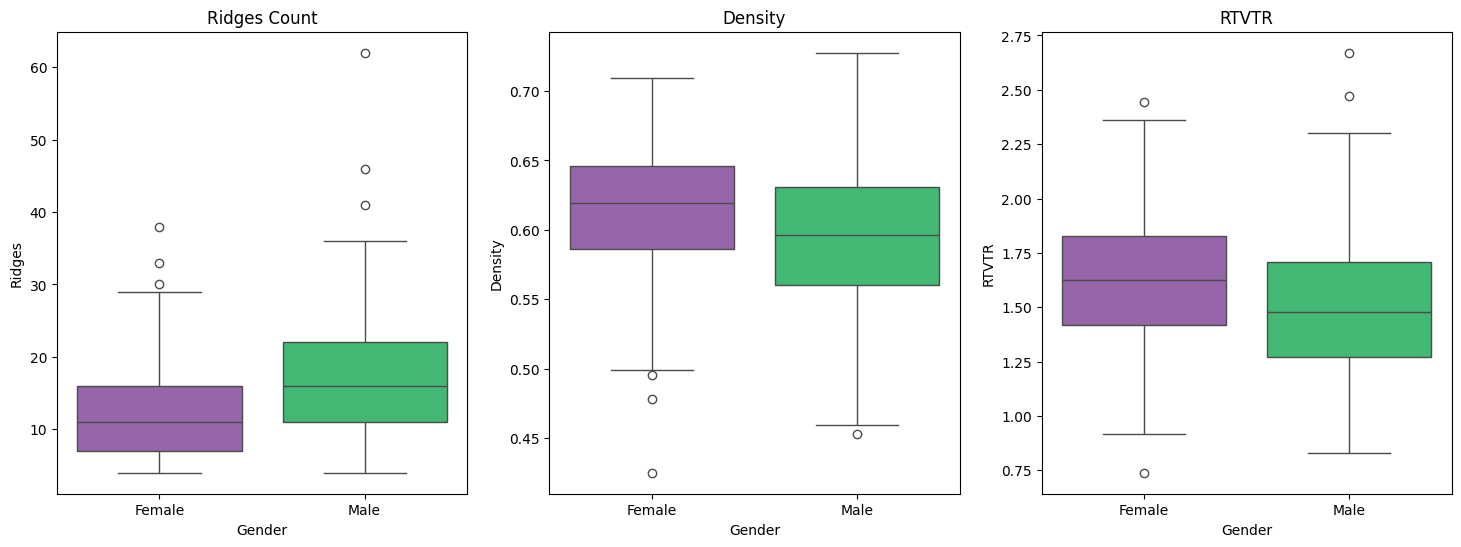

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create DataFrame
df_analysis = pd.DataFrame({
    'Gender': ['Female' if y==1 else 'Male' for y in y_test_bal],
    'Ridges': feat_test_bal[:, 0],
    'Density': feat_test_bal[:, 1],
    'RTVTR': feat_test_bal[:, 2]
})

# Drawing Boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
my_colors = {'Male': '#2ecc71', 'Female': '#9b59b6'}

sns.boxplot(x='Gender', y='Ridges', data=df_analysis, ax=axes[0], palette=my_colors)
axes[0].set_title('Ridges Count')

sns.boxplot(x='Gender', y='Density', data=df_analysis, ax=axes[1], palette=my_colors)
axes[1].set_title('Density')

sns.boxplot(x='Gender', y='RTVTR', data=df_analysis, ax=axes[2], palette=my_colors)
axes[2].set_title('RTVTR')

plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Classification Report (Balanced Test):
              precision    recall  f1-score   support

    Male (0)       0.66      0.86      0.75       184
  Female (1)       0.80      0.55      0.65       184

    accuracy                           0.71       368
   macro avg       0.73      0.71      0.70       368
weighted avg       0.73      0.71      0.70       368



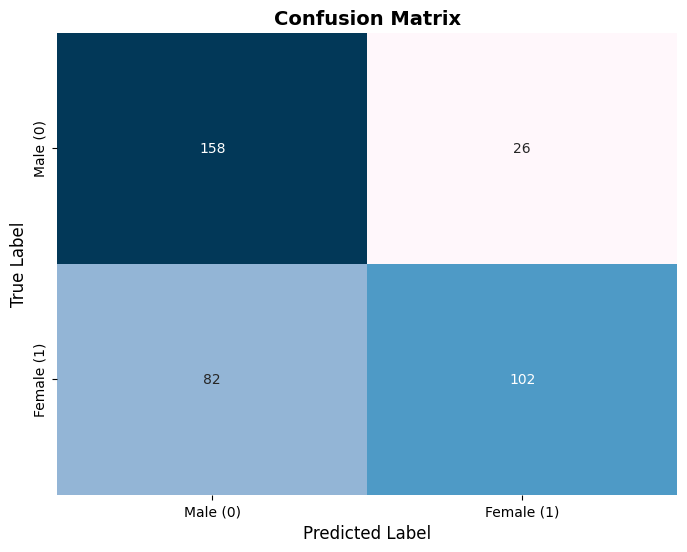

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prediction
y_pred_probs = model.predict([X_test_bal, feat_test_bal])

# Probabilities
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

target_names = ['Male (0)', 'Female (1)']

# Classification Report
print("\nClassification Report (Balanced Test):")
print(classification_report(y_test_bal, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test_bal, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="PuBu", cbar=False,
            xticklabels=target_names,
            yticklabels=target_names)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

In [14]:
# Saving model
model.save('gender_model.h5')

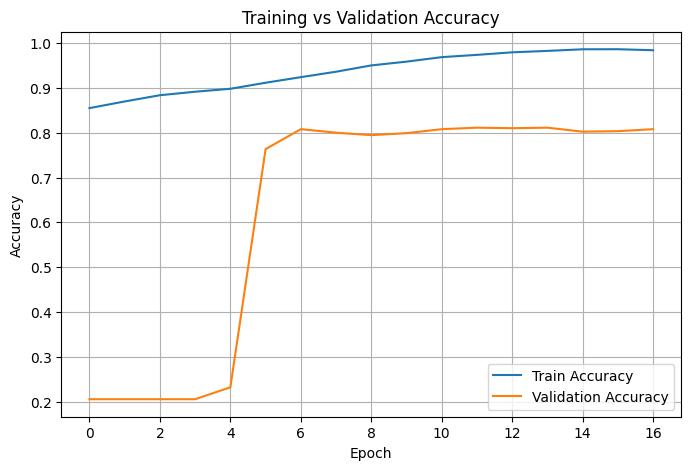

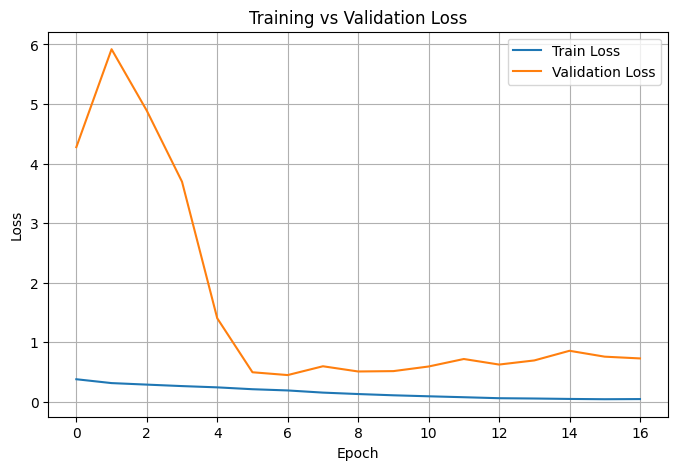

In [ ]:
# Accuracy curve
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()